### 0. Setup

In [1]:
#@title Downloads

!pip install -q --upgrade tqdm
!pip install midvoxio
!pip install onnx onnxscript onnxruntime
!pip install -U onnxruntime
!pip install lpips
!pip install onnx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 163.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 171.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.2 MB/s eta 0:00:00


In [2]:
#@title Libraries
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from midvoxio.voxio import vox_to_arr
from midvoxio.voxio import viz_vox
from midvoxio.voxio import write_list_to_vox
from midvoxio.voxio import plot_3d
from mpl_toolkits.mplot3d import Axes3D
from google.colab import drive
import scipy
import torch.optim as optim
import random
from tqdm import tqdm
import lpips
import onnx
import onnxscript


In [3]:
#@title Download/External links
!wget -O Regular_tree.vox "https://voxbox.store/api/model/download?id=8ryE8w3LOy"
!wget -O Fall_tree.vox "https://voxbox.store/api/model/download?id=rC2Fnv8YI2"
!wget -O Chicken.vox "https://voxbox.store/api/model/download?id=nTqJDfvpU9"
!wget -O Pine_tree.vox "https://voxbox.store/api/model/download?id=XHxA65ZDGj"
!wget -O Furnace.vox "https://voxbox.store/api/model/download?id=ei6SEQJPSs"
!wget -O Mug.vox "https://voxbox.store/api/model/download?id=d4cA4CJFYp"
!wget -O Mushroom.vox "https://voxbox.store/api/model/download?id=ky7oAEUGsh"
!wget -O Globe.vox "https://voxbox.store/api/model/download?id=05PJncdAqK"

--2026-04-19 00:44:06--  https://voxbox.store/api/model/download?id=8ryE8w3LOy
Resolving voxbox.store (voxbox.store)... 5.161.231.181, 2a01:4ff:f0:8ec9::1
Connecting to voxbox.store (voxbox.store)|5.161.231.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1740611 (1.7M) [application/x-authorware-bin]
Saving to: ‘Regular_tree.vox’

Regular_tree.vox    100%[===================>]   1.66M  5.09MB/s    in 0.3s    

2026-04-19 00:44:07 (5.09 MB/s) - ‘Regular_tree.vox’ saved [1740611/1740611]

--2026-04-19 00:44:07--  https://voxbox.store/api/model/download?id=rC2Fnv8YI2
Resolving voxbox.store (voxbox.store)... 5.161.231.181, 2a01:4ff:f0:8ec9::1
Connecting to voxbox.store (voxbox.store)|5.161.231.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1740505 (1.7M) [application/x-authorware-bin]
Saving to: ‘Fall_tree.vox’

Fall_tree.vox       100%[===================>]   1.66M  5.07MB/s    in 0.3s    

2026-04-19 00:44:08 (5.07 MB/s) - ‘Fall

In [4]:
VOX_FILES = [
    'Regular_tree.vox',
    'Fall_tree.vox',
    'Chicken.vox',
    'Pine_tree.vox',
    'Furnace.vox',
    'Mug.vox',
    'Mushroom.vox',
    'Globe.vox'
]

for vox_path in VOX_FILES:
    arr = vox_to_arr(vox_path, -1)
    print(f'{vox_path}: {arr.shape}')


_t in nTRN not match models, transform not applied
Regular_tree.vox: (256, 256, 256, 4)
Fall_tree.vox: (256, 256, 256, 4)
Chicken.vox: (11, 5, 10, 4)
Pine_tree.vox: (128, 128, 128, 4)
_t in nTRN not match models, transform not applied
Furnace.vox: (16, 16, 16, 4)
Mug.vox: (36, 36, 19, 4)
Mushroom.vox: (70, 71, 75, 4)
Globe.vox: (68, 68, 68, 4)


In [5]:
#@title Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found — training will be slow.")
    print("    Runtime → Change runtime type → T4 GPU")

Device : cuda
GPU    : NVIDIA L4


### 1. Perception

In [6]:
class Perception(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.perceive = nn.Conv3d(
            channels,
            channels * 4,       # identity + sobel_x + sobel_y + sobel_z
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        a = torch.tensor([1, 2, 1], dtype=torch.float32)
        b = torch.tensor([-1, 0, 1], dtype=torch.float32)

        sobel_x = torch.einsum('i,j,k->ijk', a, a, b)
        sobel_y = torch.einsum('i,j,k->ijk', a, b, a)
        sobel_z = torch.einsum('i,j,k->ijk', b, a, a)

        identity = torch.zeros(3, 3, 3, dtype=torch.float32)
        identity[1, 1, 1] = 1.0

        kernels = torch.stack([identity, sobel_x, sobel_y, sobel_z], dim=0)
        kernels = kernels.unsqueeze(1)
        kernels = kernels.repeat(channels, 1, 1, 1, 1)

        with torch.no_grad():
            self.perceive.weight.copy_(kernels)

        self.n_channels = channels

    def forward(self, x):
        return self.perceive(x)

### 2. Adaptation

In [7]:
class Adaptation(nn.Module):
    def __init__(self, channels, hidden_channels=128):
        super().__init__()
        self.adapt = nn.Sequential(
            nn.Conv3d(channels * 4, hidden_channels, kernel_size=1),  # 4x now
            nn.ReLU(),
            nn.Conv3d(hidden_channels, channels, kernel_size=1, bias=False)
        )
        nn.init.zeros_(self.adapt[-1].weight)

    def forward(self, x):
        return self.adapt(x)

### 3. LPPN

In [8]:
#@title Sine layer
class SineLayer(nn.Module):
    # SIREN-style sine activation layer [cite: 155, 156]
    def __init__(self, in_features, out_features, is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.linear.in_features, 1 / self.linear.in_features)
            else:
                self.linear.weight.uniform_(
                    -np.sqrt(6 / self.linear.in_features) / self.omega_0,
                    np.sqrt(6 / self.linear.in_features) / self.omega_0
                )

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

In [9]:
#@title LPPN
class LPPN(nn.Module):
    def __init__(self, nca_channels, out_channels=4, hidden_dim=64, harmonics=1, num_sine_layers=4):
        super().__init__()
        # u-coordinates for a cube primitive are Cartesian[cite: 92].
        # We encode them with a sinusoidal basis of the first n harmonics[cite: 107].
        # 3 coords (x,y,z) * 2 (sin, cos) * harmonics
        coord_dim = 3 * 2 * harmonics
        in_dim = nca_channels + coord_dim

        self.harmonics = harmonics

        layers = [SineLayer(in_dim, hidden_dim, is_first=True)]
        for _ in range(max(0, num_sine_layers - 1)):
            layers.append(SineLayer(hidden_dim, hidden_dim))
        layers.append(nn.Linear(hidden_dim, out_channels))
        self.net = nn.Sequential(*layers)

    def encode_coordinates(self, u):
        # u is [..., 3] inside [-1, 1] [cite: 95]
        features = []
        for n in range(1, self.harmonics + 1):
            features.append(torch.sin(np.pi * n * u))
            features.append(torch.cos(np.pi * n * u))
        return torch.cat(features, dim=-1)

    def forward(self, state, u):
        # state: [B, C, D, H, W], u: [B, 3, D, H, W]
        # Rearrange to sequence for MLP processing
        B, C, D, H, W = state.shape

        state = state.permute(0, 2, 3, 4, 1).reshape(-1, C)
        u = u.permute(0, 2, 3, 4, 1).reshape(-1, 3)

        u_encoded = self.encode_coordinates(u)

        x = torch.cat([state, u_encoded], dim=-1)
        out = self.net(x)

        # Reshape back to grid: [B, Out_C, D, H, W]
        out = out.view(B, D, H, W, -1).permute(0, 4, 1, 2, 3)
        return out

### 4. NCA

In [10]:
#@title Neural Cellular Automata
class NCA(nn.Module):
    def __init__(self, channels=16, coarse_size=32, dt=1.0, p_update=0.5, lppn_hidden=64, harmonics=1, num_sine_layers=4, lpips_weight=1.0, lpips_chunk_size=8):
        super().__init__()
        self.channels = channels
        self.dt = dt
        self.p_update = p_update
        self.coarse_size = coarse_size

        self.perception = Perception(channels)
        self.adaptation = Adaptation(channels)
        self.lppn = LPPN(channels, out_channels=4, hidden_dim=lppn_hidden, harmonics=harmonics, num_sine_layers=num_sine_layers)

        self.target_size = None
        self.scale = None
        self.lpips_weight = lpips_weight
        self.lpips_chunk_size = lpips_chunk_size
        self.lpips_metric = lpips.LPIPS(net='vgg')
        self.lpips_metric.eval()
        self.lpips_metric.requires_grad_(False)

    def step(self, x):
        pre_life_mask = self.get_living_mask(x)

        z = self.perception(x)
        dx = self.adaptation(z)

        update_mask = (torch.rand(x[:, :1, ...].shape, device=x.device) < self.p_update).float()
        x = x + self.dt * dx * update_mask
        post_life_mask = self.get_living_mask(x)
        life_mask = pre_life_mask & post_life_mask
        return x * life_mask.float()

    def get_living_mask(self, x, threshold=0.1):
        alpha = x[:, 0:1]
        return F.max_pool3d(alpha, kernel_size=3, stride=1, padding=1) > threshold

    def get_living_mask_soft(self, x, threshold=0.1, temperature=32.0):
        # Differentiable surrogate of the survival mask for loss computation.
        alpha = x[:, 0:1]
        alive_prob = torch.sigmoid((alpha - threshold) * temperature)
        return F.max_pool3d(alive_prob, kernel_size=3, stride=1, padding=1)

    def forward(self, x, steps):
        for _ in range(steps):
            x = self.step(x)
        return x
    def create_seed(self, batch_size, device='cuda'):
        depth = height = width = self.coarse_size
        seed = torch.zeros(batch_size, self.channels, depth, height, width, device=device)
        cd, ch, cw = depth // 2, height // 2, width // 2
        seed[:, 0, cd, ch, cw] = 1.0   # only channel 0 (alive) at center
        return seed

    def apply_output_activation(self, prediction):
        rgb = torch.sigmoid(prediction[:, :3, ...])
        alpha = torch.sigmoid(prediction[:, 3:4, ...])
        return torch.cat([rgb, alpha], dim=1)

    def display_voxels(self, voxel_grid, threshold=0.1, apply_activation=False):
        """
        Displays a 3D grid of RGBA voxels using matplotlib.
        voxel_grid expected shape: [4, D, H, W]
        """
        if voxel_grid.dim() == 4:
            voxel_grid = voxel_grid.unsqueeze(0)
        if apply_activation:
            voxel_grid = self.apply_output_activation(voxel_grid)
        voxel_grid = voxel_grid[0].detach().cpu().numpy()
        alpha = voxel_grid[3]

        # Determine filled voxels
        filled = alpha > threshold

        # Extract RGB and normalize for matplotlib
        colors = np.zeros(filled.shape + (4,))
        colors[..., :3] = np.clip(voxel_grid[:3].transpose(1, 2, 3, 0), 0, 1)
        colors[..., 3] = np.clip(alpha, 0, 1) # Set alpha

        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.voxels(filled, facecolors=colors, edgecolors='k', linewidth=0.1)
        plt.show()

    def load(self, target):
        device = next(self.parameters()).device
        obj = vox_to_arr(target, -1)
        obj = torch.tensor(obj, dtype=torch.float32).permute(3, 0, 1, 2)
        _, d, h, w = obj.shape
        target_size = max(d, h, w)

        pad_d0 = (target_size - d) // 2; pad_d1 = target_size - d - pad_d0
        pad_h0 = (target_size - h) // 2; pad_h1 = target_size - h - pad_h0
        pad_w0 = (target_size - w) // 2; pad_w1 = target_size - w - pad_w0
        obj = F.pad(obj, (pad_w0, pad_w1, pad_h0, pad_h1, pad_d0, pad_d1))

        if target_size < self.coarse_size:
            self.coarse_size = target_size

        self.target_rgba   = obj.to(device)
        self.target_coarse = F.interpolate(
            self.target_rgba.unsqueeze(0),
            size=(self.coarse_size,) * 3,
            mode='trilinear', align_corners=False
        ).squeeze(0)

        self.scale = target_size / self.coarse_size
        self.target_size  = target_size

        print(f"Loaded target from {target}.")
        print(f"Scale set to {self.scale}, Coarse size set to {self.coarse_size}.")
        print("Visualizing Target and Coarse grids...")

        self.display_voxels(self.target_rgba)
        self.display_voxels(self.target_coarse)


In [11]:
#@title Loss and train
def _slice_lpips_loss(self, predicted_hr, target_hr):
    """
    LPIPS is defined on 2D RGB images, so compare the decoded 3D volume
    slice-by-slice across all three axes and average the perceptual distance.
    """
    pred_rgb = predicted_hr[:, :3, ...] * predicted_hr[:, 3:4, ...]
    target_rgb = target_hr[:, :3, ...] * target_hr[:, 3:4, ...]

    pred_rgb = pred_rgb * 2.0 - 1.0
    target_rgb = target_rgb * 2.0 - 1.0

    chunk_size = self.lpips_chunk_size
    axis_losses = []
    for axis in [2, 3, 4]:
        pred_slices = pred_rgb.movedim(axis, 2)
        target_slices = target_rgb.movedim(axis, 2)
        B, C, S, H, W = pred_slices.shape
        pred_2d = pred_slices.permute(0, 2, 1, 3, 4).reshape(B * S, C, H, W)
        target_2d = target_slices.permute(0, 2, 1, 3, 4).reshape(B * S, C, H, W)

        chunk_losses = []
        for start in range(0, pred_2d.shape[0], chunk_size):
            pred_chunk = pred_2d[start:start + chunk_size]
            target_chunk = target_2d[start:start + chunk_size]
            chunk_losses.append(self.lpips_metric(pred_chunk, target_chunk).mean())

        axis_losses.append(torch.stack(chunk_losses).mean())

    return torch.stack(axis_losses).mean()

def _orthographic_projection_rgba(self, volume, axis=2, reverse=False):
    if reverse:
        volume = torch.flip(volume, dims=[axis])

    volume = volume.movedim(axis, -1)
    rgb = volume[:, :3, ...]
    alpha = volume[:, 3:4, ...].clamp(0.0, 1.0)

    transmittance = torch.cumprod(
        torch.cat([
            torch.ones_like(alpha[..., :1]),
            (1.0 - alpha[..., :-1]).clamp_min(1e-6)
        ], dim=-1),
        dim=-1
    )

    projected_rgb = torch.sum(rgb * alpha * transmittance, dim=-1)
    projected_alpha = 1.0 - torch.prod((1.0 - alpha).clamp_min(1e-6), dim=-1)
    return torch.cat([projected_rgb, projected_alpha], dim=1)

def _projection_lpips_loss(self, predicted_hr, target_hr):
    losses = []
    for axis in [2, 3, 4]:
        for reverse in [False, True]:
            pred_proj = self.orthographic_projection_rgba(predicted_hr, axis=axis, reverse=reverse)
            target_proj = self.orthographic_projection_rgba(target_hr, axis=axis, reverse=reverse)

            pred_rgb = pred_proj[:, :3, ...] * pred_proj[:, 3:4, ...]
            target_rgb = target_proj[:, :3, ...] * target_proj[:, 3:4, ...]

            pred_rgb = pred_rgb * 2.0 - 1.0
            target_rgb = target_rgb * 2.0 - 1.0
            losses.append(self.lpips_metric(pred_rgb, target_rgb).mean())

    return torch.stack(losses).mean()

def _compute_morphology_loss(self, state):
    B, C, D, H, W = state.shape

    # 1. Trilinear interpolation of the coarse NCA state [cite: 316]
    state_interpolated = F.interpolate(state, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)

    # 2. Generate Cartesian u-coordinates for the upsampled grid [cite: 191]
    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
    grid_z, grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, d_fine, device=state.device),
        torch.linspace(-1, 1, h_fine, device=state.device),
        torch.linspace(-1, 1, w_fine, device=state.device),
        indexing='ij'
    )
    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)

    # 3. Decode NCA state to high-resolution output via LPPN [cite: 255]
    predicted_hr_raw = self.lppn(state_interpolated, u_coords)
    predicted_hr = self.apply_output_activation(predicted_hr_raw)

    # Extract alphas
    target_hr = self.target_rgba
    if target_hr.dim() == 4:
        target_hr = target_hr.unsqueeze(0) # Converts [C, D, H, W] to [1, C, D, H, W]

    # Explicitly expand the target to match the current Batch size (B)
    target_hr = target_hr.expand(B, -1, -1, -1, -1)

    # Extract alphas
    pred_alpha = predicted_hr[:, 3:4, ...]
    target_alpha = target_hr[:, 3:4, ...]

    # 4. (i) RGBA reconstruction on LPPN output (Masked) [cite: 257]
    # The paper applies l1+l2 after masking both outputs by their alpha channels.
    pred_masked = predicted_hr * pred_alpha
    target_masked = target_hr * target_alpha

    rgba_loss = F.l1_loss(pred_masked, target_masked) + F.mse_loss(pred_masked, target_masked)
    lpips_loss = self.projection_lpips_loss(predicted_hr, target_hr)

    # 5. (ii) Shape loss on the NCA living mask [cite: 258, 259]
    # Use a differentiable surrogate of the survival mask so this term can train channel 0.
    living_mask_coarse = self.get_living_mask_soft(state)
    living_mask_up = F.interpolate(living_mask_coarse, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)

    shape_loss = F.l1_loss(living_mask_up, target_alpha) + F.mse_loss(living_mask_up, target_alpha)

    # Hybrid loss with LPIPS on 6 orthographic projections of the decoded volume.
    return rgba_loss + shape_loss + (self.lpips_weight * lpips_loss)

def _compute_morphology_loss_no_lpips(self, state):
    B, C, D, H, W = state.shape

    state_interpolated = F.interpolate(state, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)

    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
    grid_z, grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, d_fine, device=state.device),
        torch.linspace(-1, 1, h_fine, device=state.device),
        torch.linspace(-1, 1, w_fine, device=state.device),
        indexing='ij'
    )
    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)

    predicted_hr_raw = self.lppn(state_interpolated, u_coords)
    predicted_hr = self.apply_output_activation(predicted_hr_raw)

    target_hr = self.target_rgba
    if target_hr.dim() == 4:
        target_hr = target_hr.unsqueeze(0)
    target_hr = target_hr.expand(B, -1, -1, -1, -1)

    pred_alpha = predicted_hr[:, 3:4, ...]
    target_alpha = target_hr[:, 3:4, ...]

    pred_masked = predicted_hr * pred_alpha
    target_masked = target_hr * target_alpha
    rgba_loss = F.l1_loss(pred_masked, target_masked) + F.mse_loss(pred_masked, target_masked)

    living_mask_coarse = self.get_living_mask_soft(state)
    living_mask_up = F.interpolate(living_mask_coarse, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)
    shape_loss = F.l1_loss(living_mask_up, target_alpha) + F.mse_loss(living_mask_up, target_alpha)

    return rgba_loss + shape_loss

def _nca_alone_loss(self, state):
    """
    Optional: Evaluates the coarse NCA state directly against a coarse target.
    Useful for warm-up or ablation testing, but not part of the final hybrid paper logic.
    """
    predicted_coarse_rgba = state[:, :4, ...]
    coarse_target_alpha = self.target_coarse[:, 3:4, ...]
    pred_alpha = predicted_coarse_rgba[:, 3:4, ...]

    # Applying the paper's alpha-masking logic to the coarse grid
    pred_masked = predicted_coarse_rgba * pred_alpha
    target_masked = self.target_coarse * coarse_target_alpha

    l1_loss = F.l1_loss(pred_masked, target_masked)
    l2_loss = F.mse_loss(pred_masked, target_masked)

    return l1_loss + l2_loss

def _training_step(self, optimizer, seed_state, steps):
    """
    Full end-to-end training step: runs the NCA, computes the paper's hybrid morphology loss,
    and backpropagates.
    """
    self.train()
    optimizer.zero_grad()

    # 1. Run NCA on the coarse lattice [cite: 255]
    final_state = self.forward(seed_state, steps)

    # 2. Compute end-to-end morphology loss on high-res LPPN output [cite: 256]
    total_loss = self.compute_morphology_loss(final_state)

    total_loss.backward()

    # 3. Normalize gradients for NCA stability [cite: 277, 482]
    # Note: The paper explicitly states NOT to normalize LPPN gradients.
    torch.nn.utils.clip_grad_norm_(self.perception.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_(self.adaptation.parameters(), 1.0)

    optimizer.step()

    return total_loss.item()

def _train_morphogenesis(self, iterations=1500, lr=1e-3, batch_size=4, step_range=(32, 96), pool_size=1024, viz_log= 100):
        """
        Complete training loop with a Checkpoint Pool to prevent local minima.
        """

        device = next(self.parameters()).device
        optimizer = optim.Adam((p for p in self.parameters() if p.requires_grad), lr=lr)

        # Slower decay to give the pool time to evolve
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.3)

        if self.coarse_size is None:
            raise ValueError("Model coarse_size is not set. Run self.load(...) first.")
        D, H, W = self.coarse_size, self.coarse_size, self.coarse_size

        print(f"Initializing checkpoint pool of size {pool_size}...")
        # Create the persistent pool of states
        pool = self.create_seed(batch_size=pool_size, device=device)

        print(f"Starting training on {device} for {iterations} iterations...")

        for i in range(1, iterations + 1):
            steps = random.randint(step_range[0], step_range[1])

            # --- POOL LOGIC START ---
            # 1. Sample a random batch of indices from the pool
            batch_indices = random.sample(range(pool_size), batch_size)
            current_state = pool[batch_indices].clone()

            # 2. Replace the first item in the batch with a fresh seed
            # This ensures the NCA never forgets how to start growing from step 0
            current_state[0] = self.create_seed(batch_size=1, device=device)[0]
            # --- POOL LOGIC END ---

            self.train()
            optimizer.zero_grad()

            # Forward pass
            final_state = self.forward(current_state, steps)
            loss = self.compute_morphology_loss(final_state)

            # Overflow Regularizer (Crucial for pooled training stability)
            # Penalizes states that drift wildly outside the [-1, 1] range
            overflow_loss = torch.mean(torch.abs(final_state - torch.clamp(final_state, -1.0, 1.0)))
            total_loss = loss + (100.0 * overflow_loss)

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(self.perception.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.adaptation.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            # --- COMMIT TO POOL ---
            # Save the evolved states back into the pool for future iterations
            pool[batch_indices] = final_state.detach()

            # Logging
            if i % 100 == 0 or i == 1:
                current_lr = scheduler.get_last_lr()[0]
                print(f"Iteration {i:04d} | Loss: {loss.item():.8f} | Steps: {steps} | LR: {current_lr:.6f}")

            # Periodic Visualization
            if i % viz_log == 0 or i == iterations:
                print(f"--- Visualizing Output at Iteration {i} ---")
                with torch.no_grad():
                    test_seed = self.create_seed(batch_size=1, device=device)
                    test_final_state = self(test_seed, steps=64)

                    B, C, D_c, H_c, W_c = test_final_state.shape
                    state_interpolated = torch.nn.functional.interpolate(
                        test_final_state, size=(self.target_size,) * 3, mode='trilinear', align_corners=False
                    )

                    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
                    grid_z, grid_y, grid_x = torch.meshgrid(
                        torch.linspace(-1, 1, d_fine, device=device),
                        torch.linspace(-1, 1, h_fine, device=device),
                        torch.linspace(-1, 1, w_fine, device=device),
                        indexing='ij'
                    )
                    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)

                    decoded = self.lppn(state_interpolated, u_coords)
                    self.display_voxels(decoded[0], apply_activation=True)

def _train_morphogenesis_no_lpips(self, iterations=1500, lr=1e-3, batch_size=4, step_range=(32, 96), pool_size=1024, viz_log=100):
        """
        Same pooled training loop, but without the slice-wise LPIPS term.
        Useful for comparing paper-style reconstruction+shape loss against
        the perceptual-augmented variant.
        """

        device = next(self.parameters()).device
        optimizer = optim.Adam((p for p in self.parameters() if p.requires_grad), lr=lr)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.3)

        if self.coarse_size is None:
            raise ValueError("Model coarse_size is not set. Run self.load(...) first.")

        print(f"Initializing checkpoint pool of size {pool_size}...")
        pool = self.create_seed(batch_size=pool_size, device=device)
        print(f"Starting no-LPIPS training on {device} for {iterations} iterations...")

        for i in range(1, iterations + 1):
            steps = random.randint(step_range[0], step_range[1])
            batch_indices = random.sample(range(pool_size), batch_size)
            current_state = pool[batch_indices].clone()
            if i % 32 == 0:
                current_state[0] = self.create_seed(batch_size=1, device=device)[0]

            self.train()
            optimizer.zero_grad()

            final_state = self.forward(current_state, steps)
            loss = self.compute_morphology_loss_no_lpips(final_state)
            overflow_loss = torch.mean(torch.abs(final_state - torch.clamp(final_state, -1.0, 1.0)))
            total_loss = loss + (100.0 * overflow_loss)

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.perception.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.adaptation.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            pool[batch_indices] = final_state.detach()

            if i % 4000 == 0:
                print(f"[POOL FLUSH] Reinitializing full pool at iteration {i}")
                pool = self.create_seed(batch_size=pool_size, device=device)
                scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.3)

            if i % 100 == 0 or i == 1:
                current_lr = scheduler.get_last_lr()[0]
                print(f"[NO LPIPS] Iteration {i:04d} | Loss: {loss.item():.8f} | Steps: {steps} | LR: {current_lr:.6f}")

            if i % viz_log == 0 or i == iterations:
                print(f"--- Visualizing No-LPIPS Output at Iteration {i} ---")
                with torch.no_grad():
                    test_seed = self.create_seed(batch_size=1, device=device)
                    test_final_state = self(test_seed, steps=64)

                    B, C, D_c, H_c, W_c = test_final_state.shape
                    state_interpolated = torch.nn.functional.interpolate(
                        test_final_state, size=(self.target_size,) * 3, mode='trilinear', align_corners=False
                    )

                    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
                    grid_z, grid_y, grid_x = torch.meshgrid(
                        torch.linspace(-1, 1, d_fine, device=device),
                        torch.linspace(-1, 1, h_fine, device=device),
                        torch.linspace(-1, 1, w_fine, device=device),
                        indexing='ij'
                    )
                    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)
                    decoded = self.lppn(state_interpolated, u_coords)
                    self.display_voxels(decoded[0], apply_activation=True)

def _test_seed_rollout(self, steps=64, render_size=None, display=True):
    device = next(self.parameters()).device
    with torch.no_grad():
        seed = self.create_seed(batch_size=1, device=device)
        final_state = self(seed, steps=steps)
        decoded = self.decode(final_state, render_size=render_size)

        result = {
            'seed': seed[0],
            'coarse_state': final_state[0],
            'decoded': decoded[0],
            'alive_cells': int((final_state[0, 0] > 0.1).sum().item()),
        }

        render_shape = tuple(decoded.shape[-3:])
        print(f"[SEED TEST] steps={steps} render_size={render_shape} alive_cells={result['alive_cells']}")

        if display:
            print('[SEED TEST] coarse living mask')
            coarse_preview = torch.zeros(4, *final_state.shape[2:], device=device)
            coarse_preview[3] = final_state[0, 0]
            self.display_voxels(coarse_preview)
            print('[SEED TEST] decoded output')
            self.display_voxels(decoded[0])

    return result

def _diagnose(self, steps=64):
    device = next(self.parameters()).device
    with torch.no_grad():
        seed = self.create_seed(batch_size=1, device=device)
        print(f"[SEED]  alive cells: {(seed[0,0]>0.1).sum().item()}")

        for s in [1, 4, 8, 16, 32, 64]:
            x = self(seed.clone(), steps=s)
            alive = (x[0,0] > 0.1).sum().item()
            ch0 = x[0,0]
            print(f"[NCA s={s:3d}]  alive: {alive:5d}  ch0 min:{ch0.min():.3f} max:{ch0.max():.3f} mean:{ch0.mean():.4f}")

        state_interp = F.interpolate(x, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)
        print(f"\n[INTERP]  shape: {tuple(state_interp.shape)}  min:{state_interp.min():.3f} max:{state_interp.max():.3f}")

        d, h, w = state_interp.shape[2:]
        grid_z, grid_y, grid_x = torch.meshgrid(
            torch.linspace(-1, 1, d, device=device),
            torch.linspace(-1, 1, h, device=device),
            torch.linspace(-1, 1, w, device=device),
            indexing='ij'
        )
        u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0)
        decoded_raw = self.lppn(state_interp, u_coords)
        decoded = self.apply_output_activation(decoded_raw)

        print(f"\n[LPPN]  R  min:{decoded[0,0].min():.3f} max:{decoded[0,0].max():.3f}")
        print(f"[LPPN]  G  min:{decoded[0,1].min():.3f} max:{decoded[0,1].max():.3f}")
        print(f"[LPPN]  B  min:{decoded[0,2].min():.3f} max:{decoded[0,2].max():.3f}")
        print(f"[LPPN]  A  min:{decoded[0,3].min():.3f} max:{decoded[0,3].max():.3f} mean:{decoded[0,3].mean():.4f}")

        print(f"\n[TARGET] A  min:{self.target_rgba[3].min():.3f} max:{self.target_rgba[3].max():.3f} mean:{self.target_rgba[3].mean():.4f}")

NCA.test_seed_rollout = _test_seed_rollout
NCA.diagnose = _diagnose
NCA.training_step = _training_step
NCA.slice_lpips_loss = _slice_lpips_loss
NCA.orthographic_projection_rgba = _orthographic_projection_rgba
NCA.projection_lpips_loss = _projection_lpips_loss
NCA.compute_morphology_loss = _compute_morphology_loss
NCA.compute_morphology_loss_no_lpips = _compute_morphology_loss_no_lpips
NCA.nca_alone_loss = _nca_alone_loss
NCA.train_morphogenesis = _train_morphogenesis
NCA.train_morphogenesis_no_lpips = _train_morphogenesis_no_lpips


### 5. Instantiate & Inspect the Model

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 239MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Loaded target from Mushroom.vox.
Scale set to 4.6875, Coarse size set to 16.
Visualizing Target and Coarse grids...


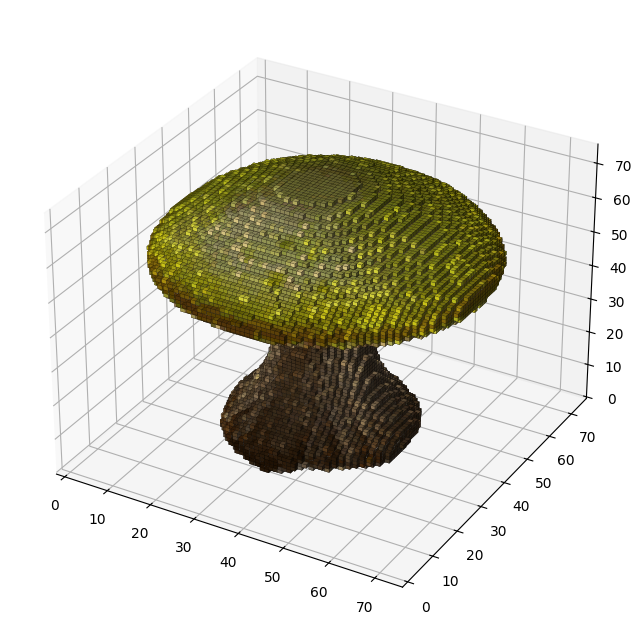

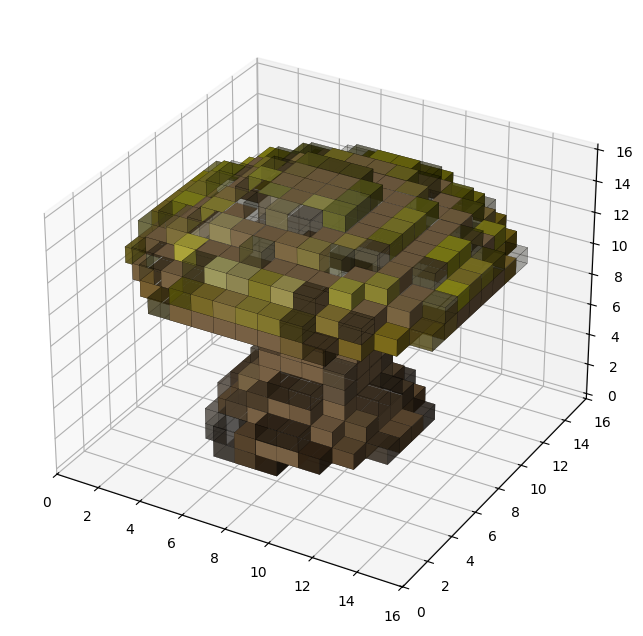

[SEED]  alive cells: 1
[NCA s=  1]  alive:     1  ch0 min:0.000 max:1.000 mean:0.0002
[NCA s=  4]  alive:     1  ch0 min:0.000 max:1.000 mean:0.0002
[NCA s=  8]  alive:     1  ch0 min:0.000 max:1.000 mean:0.0002
[NCA s= 16]  alive:     1  ch0 min:0.000 max:1.000 mean:0.0002
[NCA s= 32]  alive:     1  ch0 min:0.000 max:1.000 mean:0.0002
[NCA s= 64]  alive:     1  ch0 min:0.000 max:1.000 mean:0.0002

[INTERP]  shape: (1, 48, 75, 75, 75)  min:0.000 max:0.796

[LPPN]  R  min:0.379 max:0.744
[LPPN]  G  min:0.412 max:0.728
[LPPN]  B  min:0.315 max:0.621
[LPPN]  A  min:0.426 max:0.746 mean:0.5868

[TARGET] A  min:0.000 max:1.000 mean:0.1913
─────────────────────────────────────────────
  Model summary
─────────────────────────────────────────────
  NCA   (Perception + Adaptation) :   36,032 params
  LPPN  (SineNet + output head)   :   53,956 params
  LPPN overhead                   : 149.7 %
  Total                           :   89,988 params
─────────────────────────────────────────────
  Co

In [12]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_CHANNELS   = 48     # NCA hidden state channels (paper uses 16)
COARSE_SIZE  = 16     # NCA grid resolution (paper uses 128 for high quality)
N_FREQS      = 4      # sinusoidal harmonics for local coords
LPPN_HIDDEN  = 96     # LPPN hidden width
LPPN_LAYERS  = 6      # LPPN depth (sine layers)

nca = NCA(
    channels         = N_CHANNELS,
    coarse_size      = COARSE_SIZE,
    lppn_hidden      = LPPN_HIDDEN,
    harmonics        = N_FREQS,
    num_sine_layers  = LPPN_LAYERS,
).to(DEVICE)
nca.load("Mushroom.vox")
nca.diagnose()
# ── Parameter summary ────────────────────────────────────────────────────────
nca_params  = sum(p.numel() for p in nca.perception.parameters()) + \
              sum(p.numel() for p in nca.adaptation.parameters())
lppn_params = sum(p.numel() for p in nca.lppn.parameters())
total       = nca_params + lppn_params

print(f"{'─'*45}")
print(f"  Model summary")
print(f"{'─'*45}")
print(f"  NCA   (Perception + Adaptation) : {nca_params:>8,} params")
print(f"  LPPN  (SineNet + output head)   : {lppn_params:>8,} params")
print(f"  LPPN overhead                   : {lppn_params/nca_params*100:.1f} %")
print(f"  Total                           : {total:>8,} params")
print(f"{'─'*45}")
print(f"  Coarse grid  : {COARSE_SIZE}×{COARSE_SIZE}")
print(f"  Render size  : {nca.target_size}×{nca.target_size}")
print(f"  Device       : {DEVICE}")

# ── Forward-pass shape check ──────────────────────────────────────────────────
def _decode(self, state, render_size=None):
    """Decode coarse NCA state to high-resolution RGBA via LPPN."""
    B = state.shape[0]
    if render_size is None:
        render_size = self.target_size
    if isinstance(render_size, int):
        render_size = (render_size, render_size, render_size)
    state_interpolated = F.interpolate(
        state, size=render_size, mode='trilinear', align_corners=False
    )
    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
    grid_z, grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, d_fine, device=state.device),
        torch.linspace(-1, 1, h_fine, device=state.device),
        torch.linspace(-1, 1, w_fine, device=state.device),
        indexing='ij'
    )
    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)
    decoded_raw = self.lppn(state_interpolated, u_coords)
    return self.apply_output_activation(decoded_raw)

NCA.decode = _decode


### TEST

Initializing checkpoint pool of size 128...
Starting no-LPIPS training on cuda:0 for 1000 iterations...
[NO LPIPS] Iteration 0001 | Loss: 0.80358434 | Steps: 46 | LR: 0.000100
[NO LPIPS] Iteration 0100 | Loss: 0.34015569 | Steps: 86 | LR: 0.000100
[NO LPIPS] Iteration 0200 | Loss: 0.26279002 | Steps: 94 | LR: 0.000100
[NO LPIPS] Iteration 0300 | Loss: 0.82051986 | Steps: 62 | LR: 0.000100
[NO LPIPS] Iteration 0400 | Loss: 0.61026418 | Steps: 53 | LR: 0.000100
[NO LPIPS] Iteration 0500 | Loss: 0.33977053 | Steps: 52 | LR: 0.000100
[NO LPIPS] Iteration 0600 | Loss: 0.32317761 | Steps: 44 | LR: 0.000100
[NO LPIPS] Iteration 0700 | Loss: 0.33742690 | Steps: 51 | LR: 0.000100
[NO LPIPS] Iteration 0800 | Loss: 0.40394753 | Steps: 62 | LR: 0.000100
[NO LPIPS] Iteration 0900 | Loss: 0.59857923 | Steps: 54 | LR: 0.000100
[NO LPIPS] Iteration 1000 | Loss: 0.36697716 | Steps: 34 | LR: 0.000100
--- Visualizing No-LPIPS Output at Iteration 1000 ---


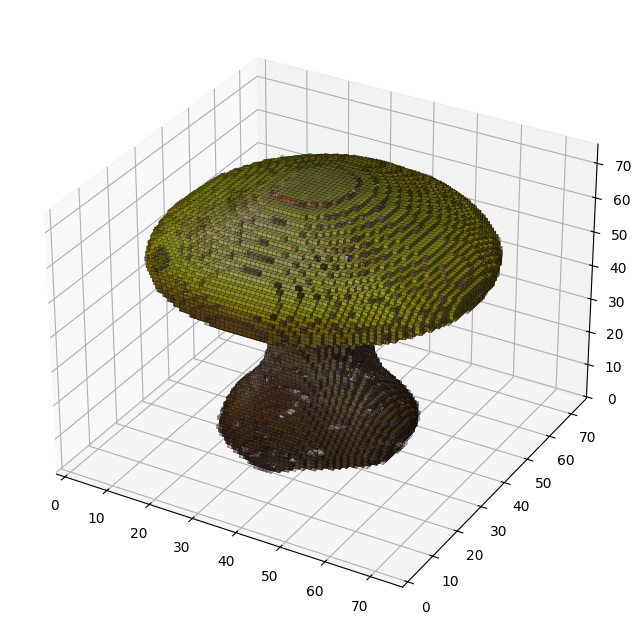

In [13]:
nca.train_morphogenesis_no_lpips(
    iterations=1000,
    lr=1e-4,
    batch_size=2,
    step_range=(32, 96),
    pool_size=128,
    viz_log=1000
)

[SEED TEST] steps=96 render_size=(75, 75, 75) alive_cells=1
[SEED TEST] coarse living mask


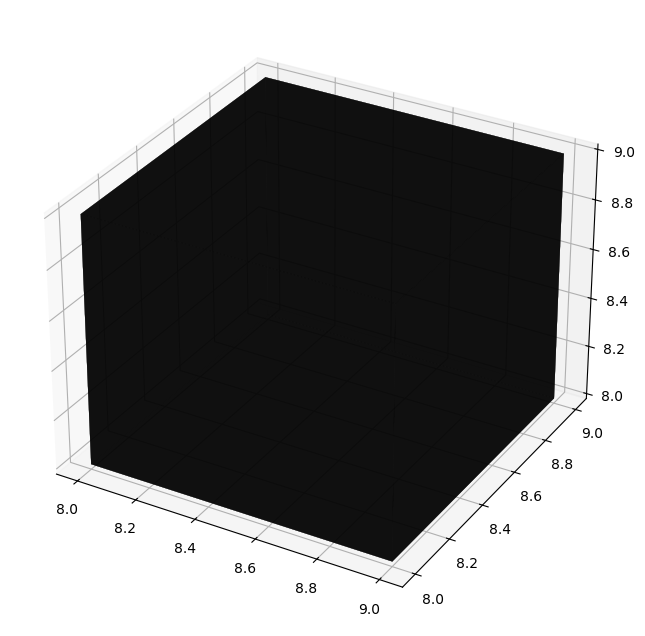

[SEED TEST] decoded output


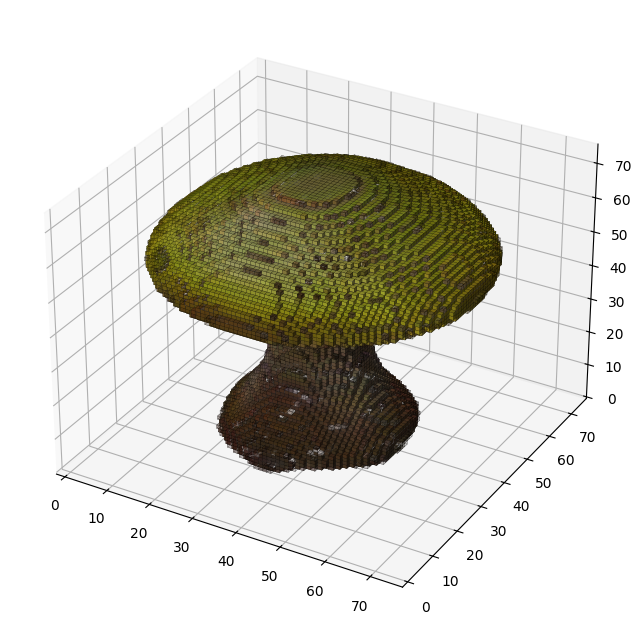

Native decoded shape: (4, 75, 75, 75)


In [14]:
seed_test_native = nca.test_seed_rollout(steps=96, render_size=nca.target_size, display=True)
print(f"Native decoded shape: {tuple(seed_test_native['decoded'].shape)}")

# seed_test_2x = nca.test_seed_rollout(steps=96, render_size=nca.target_size * 2, display=False)
# print(f"2x decoded shape: {tuple(seed_test_2x['decoded'].shape)}")
# nca.display_voxels(seed_test_2x['decoded'])


### SAVE

In [15]:
import json
from pathlib import Path

import numpy as np

def export_nca_weights(nca, json_path="nca_weights.json", bin_path="nca_weights.bin", manifest_path="nca_manifest.json"):
    state_dict = nca.state_dict()
    sections = {'perception': {}, 'adaptation': {}, 'lppn': {}}

    for name, tensor in state_dict.items():
        prefix, param_name = name.split('.', 1)
        if prefix not in sections:
            continue
        flat = tensor.detach().cpu().numpy().astype(np.float32).reshape(-1)
        sections[prefix][param_name] = {
            'shape': list(tensor.shape),
            'data': flat.tolist(),
        }

    weights = {
        'meta': {
            'channels': nca.channels,
            'coarse_size': nca.coarse_size,
            'target_size': nca.target_size,
            'scale': nca.scale,
        },
        **sections,
    }

    with open(json_path, 'w') as f:
        json.dump(weights, f)

    manifest = {'meta': weights['meta']}
    offset = 0
    total_bytes = 0

    with open(bin_path, 'wb') as f:
        for section in ['perception', 'adaptation', 'lppn']:
            manifest[section] = {}
            for name, entry in weights[section].items():
                data = np.array(entry['data'], dtype=np.float32)
                f.write(data.tobytes())
                manifest[section][name] = {
                    'offset': offset,
                    'shape': entry['shape'],
                    'count': int(data.size),
                }
                offset += data.nbytes
                total_bytes += data.nbytes

    with open(manifest_path, 'w') as f:
        json.dump(manifest, f, indent=2)

    print(f"JSON: {Path(json_path).resolve()}")
    print(f"Binary: {total_bytes / 1e3:.1f} KB -> {Path(bin_path).resolve()}")
    print(f"Manifest: {Path(manifest_path).resolve()}")


export_nca_weights(nca)


JSON: /content/nca_weights.json
Binary: 360.0 KB -> /content/nca_weights.bin
Manifest: /content/nca_manifest.json
